# 4b. Default Prediction: XGBoost

### Outline of this notebook:
* **Section 1:** Objective  
* **Section 2:** Load Cleaned Dataset  
* **Section 3:** Feature Preprocessing  
  * 3.1 Define feature types  
  * 3.2 Train-validation-test split (time-based)  
  * 3.3 Preprocessing pipeline   
* **Section 4:** XGBoost  
  * 4.1 Hyperparameter tuning  
  * 4.2 Refit on train + val  
  * 4.3 Test evaluation  
  * 4.4 Feature importance  
* **Section 5:** SHAP Analysis

---
## Section 1: Objective

In this notebook, we build and evaluate an **XGBoost** model for predicting loan default.

Compared to logistic regression, XGBoost can capture **nonlinear relationships and interactions** between variables without requiring manual feature engineering, often achieving stronger predictive performance in credit risk settings.

Unlike Random Forest (which builds independent trees and averages predictions), **XGBoost builds trees sequentially**: each new tree focuses on correcting the residual errors of the previous ones. This often leads to better performance, especially on large tabular datasets.

The model provides feature importance via **SHAP values**, offering a more interpretable view of individual predictions than standard tree importance scores.

---
## Section 2: Load Cleaned Dataset 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve
)

import json
import time
from datetime import timedelta
import shap

In [5]:
df_cleaned = pd.read_parquet("../data/processed/LendingClub_features.parquet")

In [6]:
df_cleaned.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,income_to_loan_ratio,payment_to_income,inq_per_credit_year,dti_x_int_rate,loan_to_installment,delinq_rate,fico_band,dti_band,unemployment_rate,fed_funds_rate
0,5000.0,36.0,0.1065,162.87,B,B2,10.0,RENT,24000.0,Verified,...,4.800000,0.069444,0.024094,2.944725,30.699331,0.0,670_739,high,8.5,0.07
1,2500.0,60.0,0.1527,59.83,C,C4,0.5,RENT,30000.0,Source Verified,...,12.000000,0.016667,0.183491,0.152700,41.785057,0.0,670_739,very_low,8.5,0.07
2,2400.0,36.0,0.1596,84.33,C,C5,10.0,RENT,12252.0,Not Verified,...,5.105000,0.065295,0.081102,1.391712,28.459623,0.0,670_739,very_low,8.5,0.07
3,10000.0,36.0,0.1349,339.31,C,C1,10.0,RENT,49200.0,Source Verified,...,4.920000,0.067751,0.032880,2.698000,29.471575,0.0,670_739,medium,8.5,0.07
4,3000.0,60.0,0.1269,67.79,B,B5,1.0,RENT,80000.0,Source Verified,...,26.666667,0.007500,0.000000,2.276586,44.254314,0.0,670_739,medium,8.5,0.07


#### Limit to pre-COVID loans

To ensure a stable and consistent economic environment, I exclude observations from the COVID-19 period and restrict the analysis to loans issued up to 2019. This avoids potential distortions driven by the unprecedented shocks during the pandemic.

In [8]:
df_cleaned['issue_d'].agg(['min', 'max'])

min   2007-06-01
max   2020-09-01
Name: issue_d, dtype: datetime64[ns]

In [9]:
print(f"Number of observations before restricting to 2019-12-01: {df_cleaned.shape[0]:,}")

Number of observations before restricting to 2019-12-01: 1,860,765


In [10]:
df_cleaned = df_cleaned[df_cleaned['issue_d'] <= '2019-12-01']

In [11]:
print(f"Number of observations after restricting to 2019-12-01: {df_cleaned.shape[0]:,}")

Number of observations after restricting to 2019-12-01: 1,856,478


---
## Section 3: Feature Preprocessing

In this section, I prepare the features for tree-based models using a streamlined preprocessing pipeline.

The main steps are as follows:

- **3.1: Define feature types**: Separate variables into numerical and categorical features.

- **3.2: Train-validation-test split**

- **3.3: Build preprocessing pipeline**:
  - **Categorical variables**: Impute missing values using the most frequent value and apply one-hot encoding, converting each category into binary (0/1) indicator variables.
  - **Numerical variables**: Impute missing values using the median.
  - Unlike logistic regression, tree-based models do not require feature scaling, as they are not sensitive to the scale of input variables.
  - These steps are implemented using `ColumnTransformer` and `Pipeline` from `sklearn`, and are applied during model training rather than directly modifying `df_cleaned`. This ensures consistency, reproducibility, and prevents data leakage.

### 🔷 3.1: Define feature types

In [14]:
# 1. Target variable
target = 'default'

# 2. Variables to drop (before modeling)
drop_cols = ['grade', 'sub_grade', 'int_rate', 'zip_code', 'addr_state',
             'dti', 'fico_range_low']
    # grade, sub_grade, int_rate:
    #  - assigned by LendingClub's internal risk model at origination
    #  - using them would be circular: they are outputs of a prior credit
    #    assessment, not independent borrower characteristics
    #  - including them would inflate model performance without adding
    #    genuine predictive signal from borrower fundamentals
    # addr_state, zip_code:
    #  - dropped to avoid potential proxy effects for protected characteristics
    #    and mitigate fairness / regulatory concerns in credit risk modeling
    # dti, fico_range_low
    #  - dropped as their bands are included instead

# 3. Time-related (handle separately)
date_cols = ['issue_d']

# 4. Categorical features
categorical_cols = [
    #'sub_grade', 
    'home_ownership', 'verification_status',
    'purpose',
    'initial_list_status', 'application_type',
    'fico_band', 'dti_band'
]

# 5. Numeric features (all the others)
numeric_cols = [
    col for col in df_cleaned.columns
    if col not in categorical_cols + date_cols + drop_cols + [target]
]

# 6. Final check
print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))
print("Date:", date_cols)

Numeric: 74
Categorical: 7
Date: ['issue_d']


In [15]:
# print(numeric_cols) ## Checking numeric features 

### 🔷 3.2: Train-validation-test split (time-based)

In [17]:
# Start from original data
X = df_cleaned.copy()

# Drop unnecessary columns
X = X.drop(columns=[col for col in drop_cols if col in X.columns])

# Target
y = df_cleaned[target]

# Combine
df_model = X.copy()
df_model[target] = y

# Sort by issue date
df_model = df_model.sort_values("issue_d")

# Split indices
n = len(df_model)
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

# Split data (time-based)
X_train = df_model.iloc[:train_end].drop(columns=[target])
y_train = df_model.iloc[:train_end][target]

X_val = df_model.iloc[train_end:val_end].drop(columns=[target])
y_val = df_model.iloc[train_end:val_end][target]

X_test = df_model.iloc[val_end:].drop(columns=[target])
y_test = df_model.iloc[val_end:][target]

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (1113886, 82)
Validation size: (371296, 82)
Test size: (371296, 82)


In [18]:
# Check date ranges
print(f"Train date range: {X_train['issue_d'].min().date()} → {X_train['issue_d'].max().date()}")
print(f"Validation date range: {X_val['issue_d'].min().date()} → {X_val['issue_d'].max().date()}")
print(f"Test date range: {X_test['issue_d'].min().date()} → {X_test['issue_d'].max().date()}")

Train date range: 2007-06-01 → 2016-07-01
Validation date range: 2016-07-01 → 2017-08-01
Test date range: 2017-08-01 → 2019-12-01


In [19]:
# [Important] Drop time variable (not used for prediction)
X_train = X_train.drop(columns=["issue_d"])
X_val = X_val.drop(columns=["issue_d"]) 
X_test  = X_test.drop(columns=["issue_d"])

In [20]:
## Combined train + val dataset for final model refit after hyperparameter tuning
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

print(f"Train+Val size: {X_trainval.shape[0]:,} rows")

Train+Val size: 1,485,182 rows


### 🔷 3.3: Build Preprocessing Pipeline

To ensure consistent and reproducible feature transformations, I construct a preprocessing pipeline using `ColumnTransformer` and `Pipeline` from `sklearn`.

- **Categorical variables**:
  - Missing values are imputed using the most frequent value.
  - Variables are then one-hot encoded, converting each category into a binary (0/1) indicator variable.

- **Numerical variables**:
  - Missing values are imputed using the median.
  - Unlike logistic regression, feature scaling is not applied, as tree-based models are not sensitive to the scale of input variables.

These transformations are applied within the modeling pipeline during training, rather than directly modifying the dataset. This ensures that the same preprocessing steps are consistently applied across training, validation, and test sets, and helps prevent data leakage.

In [22]:
# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Numerical pipeline (no scaling for tree models)
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Combined preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_cols),
    ("cat", cat_pipeline, categorical_cols)
])

print("Preprocessing pipeline ready (tree-based).")

Preprocessing pipeline ready (tree-based).


In [23]:
### 🔷 4.3: Test evaluation

## Load shared threshold (F1-optimal from full logistic model in notebook 4a)
with open("../outputs/threshold.json") as f:
    threshold = json.load(f)["threshold"]

print(f"Shared threshold: {threshold:.4f}")

Shared threshold: 0.2097


---
## Section 4: XGBoost

### 🔷 4.1: Hyperparameter tuning

We tune a small grid over key XGBoost hyperparameters using validation AUC:
- `max_depth`: controls tree depth and model complexity
- `learning_rate`: shrinkage applied to each tree's contribution
- `subsample` / `colsample_bytree`: row and column subsampling per tree (regularization)
- `min_child_weight`: minimum sum of instance weights in a leaf (controls overfitting)

In [25]:
## Build baseline pipeline
xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

In [26]:
## Fit on training data
start = time.time()

## Fit model
xgb_pipeline.fit(X_train, y_train)

end = time.time()

elapsed = timedelta(seconds=end - start)

print(f"XGBoost = Training time: {elapsed}")

XGBoost = Training time: 0:04:12.379244


In [27]:
param_grid_xgb = [
    {"max_depth": 4, "learning_rate": 0.1,  "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5},
    {"max_depth": 6, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5},
    {"max_depth": 6, "learning_rate": 0.05, "subsample": 0.7, "colsample_bytree": 0.7, "min_child_weight": 10},
    {"max_depth": 8, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5},
    {"max_depth": 8, "learning_rate": 0.03, "subsample": 0.6, "colsample_bytree": 0.7, "min_child_weight": 10},
]

results_xgb = []

for params in param_grid_xgb:

    model_xgb = Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            min_child_weight=params["min_child_weight"],
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        ))
    ])

    model_xgb.fit(X_train, y_train)

    y_val_proba_xgb = model_xgb.predict_proba(X_val)[:, 1]
    auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)

    results_xgb.append({
        "params": params,
        "val_auc": auc_xgb,
        "model": model_xgb
    })

best_result_xgb = max(results_xgb, key=lambda x: x["val_auc"])
best_model_xgb = best_result_xgb["model"]

print("Best params:", best_result_xgb["params"])
print("Best validation AUC:", best_result_xgb["val_auc"])

Best params: {'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5}
Best validation AUC: 0.7222444395383396


In [28]:
## Refit best XGB on train + val combined
best_params_xgb = best_result_xgb["params"]

best_model_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=best_params_xgb["max_depth"],
        learning_rate=best_params_xgb["learning_rate"],
        subsample=best_params_xgb["subsample"],
        colsample_bytree=best_params_xgb["colsample_bytree"],
        min_child_weight=best_params_xgb["min_child_weight"],
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

start = time.time()
best_model_xgb.fit(X_trainval, y_trainval)
print(f"XGB refit on train+val — time: {timedelta(seconds=time.time()-start)}")

XGB refit on train+val — time: 0:07:45.810657


### 🔷 4.2: Refit on train + val

In [30]:
y_test_proba_xgb = best_model_xgb.predict_proba(X_test)[:, 1]
y_test_pred_xgb = (y_test_proba_xgb >= threshold).astype(int)

print("XGBoost Test Performance:")
print("AUC:      ", roc_auc_score(y_test, y_test_proba_xgb))
print("Precision:", precision_score(y_test, y_test_pred_xgb))
print("Recall:   ", recall_score(y_test, y_test_pred_xgb))
print("F1:       ", f1_score(y_test, y_test_pred_xgb))

XGBoost Test Performance:
AUC:       0.7234813604438534
Precision: 0.35381641937498143
Recall:    0.7044614947428247
F1:        0.471048370815206


The XGBoost model achieves **AUC ≈ 0.723**, a meaningful improvement over the logistic regression models (~0.700 best), suggesting that nonlinear relationships and feature interactions add genuine predictive value beyond what a linear model can capture.

Precision (0.35) and recall (0.70) both improve over the best logistic regression specifications (precision ~0.34, recall ~0.67–0.68), with a higher F1 (0.47 vs. ~0.46), indicating that XGBoost identifies a greater share of actual defaulters at the shared threshold.

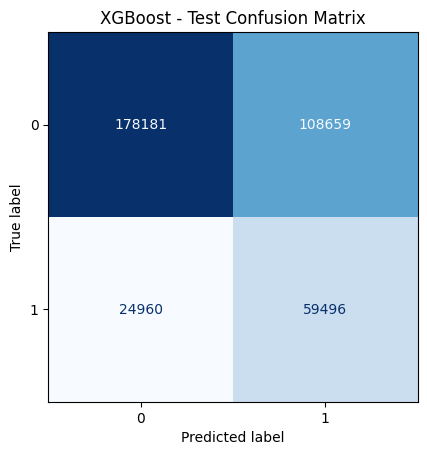

In [32]:
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot(cmap="Blues", colorbar=False)

plt.title("XGBoost - Test Confusion Matrix")
plt.show()

### 🔷 4.4: Feature importance

We examine feature importance using **permutation importance** — measuring how much model
performance (ROC-AUC) drops when each feature's values are randomly shuffled on the test
set. Features that cause a larger drop when permuted are considered more important.

In [33]:
feature_names_xgb = best_model_xgb.named_steps["preprocess"].get_feature_names_out()
importances_xgb = best_model_xgb.named_steps["model"].feature_importances_

feat_imp_xgb = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": importances_xgb
}).sort_values("importance", ascending=False)

display(feat_imp_xgb.head(20))

,feature,importance
1,num__term,0.207339
69,num__dti_x_int_rate,0.111215
70,num__loan_to_installment,0.057225
101,cat__fico_band_625_669,0.031858
109,cat__dti_band_very_low,0.030843
106,cat__dti_band_low,0.025725
103,cat__fico_band_740_799,0.023243
80,cat__verification_status_Not Verified,0.021722
79,cat__home_ownership_RENT,0.019387
30,num__acc_open_past_24mths,0.017971


XGBoost identifies **loan structure** (`term`, `loan_to_installment`) and **repayment
stress** (`dti_x_int_rate`) as the dominant predictors, together accounting for the
largest share of the model's predictive contribution. **Credit quality bands** (`fico_band`,
`dti_band`) rank prominently next, followed by **borrower characteristics**
(`home_ownership`, `verification_status`) and **credit activity** variables
(`acc_open_past_24mths`, `avg_cur_bal`, `mort_acc`). Macroeconomic conditions
(`unemployment_rate`) also contribute meaningfully. This ranking is broadly consistent
with logistic regression's permutation importance, though `dti_x_int_rate` rises notably —
reflecting XGBoost's ability to exploit nonlinear interactions that a linear model cannot
capture.

Note that XGBoost importance scores:
- Do **not indicate direction** (positive vs. negative effect on default probability)
- Capture **nonlinear effects and interactions** automatically
- Reflect how much each feature reduces prediction error across all trees

SHAP values in the next section provide a more complete picture — including direction
and interaction effects at the individual loan level.

---
## 🔷 Section 5: SHAP Analysis

SHAP (SHapley Additive exPlanations) provides theoretically grounded feature attributions
based on cooperative game theory. Unlike permutation importance in Section 4.4 — which
measures the aggregate drop in model performance when a feature is shuffled — SHAP values
decompose each individual prediction into additive feature contributions, enabling both
**global** (population-level) and **local** (individual loan) interpretation.

- **5.1**: Global bar chart — mean |SHAP| across test set (overall feature importance with direction)
- **5.2**: Beeswarm plot — distribution of SHAP values per feature (effect size and direction)
- **5.3**: Dependence plots — how the model's output changes as a function of top features

We use `TreeExplainer`, which is exact and efficient for tree-based models.

### 🔷 5.1: Compute SHAP values

In [37]:
# Transform test set through the preprocessing pipeline
X_test_transformed = best_model_xgb.named_steps["preprocess"].transform(X_test)
feature_names = best_model_xgb.named_steps["preprocess"].get_feature_names_out()

# Random sample for speed (SHAP on 370k rows is slow)
np.random.seed(42)
sample_idx = np.random.choice(X_test_transformed.shape[0], size=5000, replace=False)
X_shap = X_test_transformed[sample_idx]

# Compute SHAP values using TreeExplainer (exact, efficient for XGBoost)
explainer = shap.TreeExplainer(best_model_xgb.named_steps["model"])
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values computed — shape: {shap_values.shape}")

SHAP values computed — shape: (5000, 110)


### 🔷 5.2: Global feature importance (mean |SHAP|)

/var/folders/61/4f46qg1x30s7x09xxzgv1qb40000gn/T/ipykernel_4970/3912846761.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values,


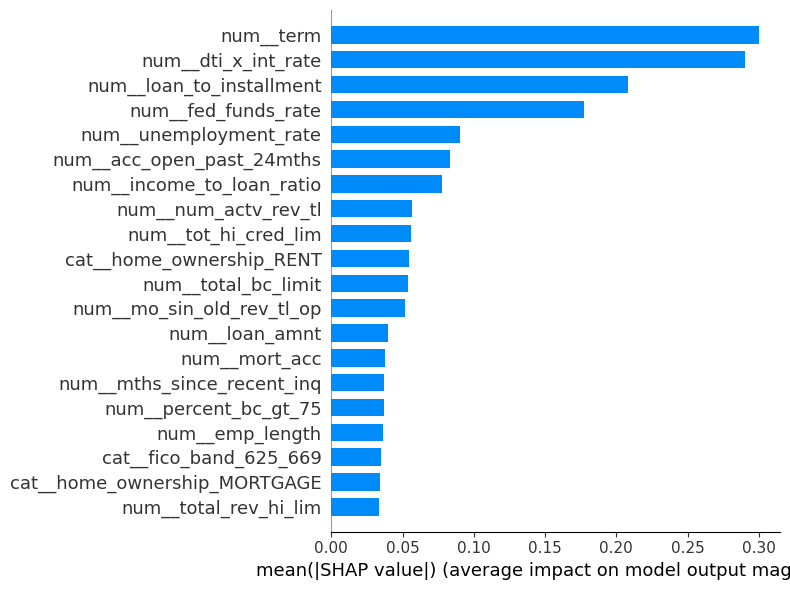

In [39]:
shap.summary_plot(shap_values, 
                  X_shap, 
                  feature_names=feature_names, 
                  plot_type="bar", 
                  max_display=20, 
                  plot_size=(8, 6))

The SHAP bar chart confirms that **loan structure** (`term`, `loan_to_installment`) and
**repayment stress** (`dti_x_int_rate`) are the three dominant drivers, together
accounting for the majority of average prediction impact. **Macroeconomic conditions**
(`fed_funds_rate`, `unemployment_rate`) rank notably high — higher than in permutation
importance — reflecting XGBoost's ability to capture nonlinear vintage effects tied to
the interest rate environment. Beyond the top tier, importance declines gradually across
credit capacity (`tot_hi_cred_lim`, `total_bc_limit`), borrower profile
(`home_ownership`, `income_to_loan_ratio`, `emp_length`), and account activity variables
(`acc_open_past_24mths`, `mo_sin_old_rev_tl_op`), consistent with signal being broadly
distributed across features.

### 🔷 5.3: Beeswarm plot (direction + magnitude)

/var/folders/61/4f46qg1x30s7x09xxzgv1qb40000gn/T/ipykernel_4970/1617525767.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values,


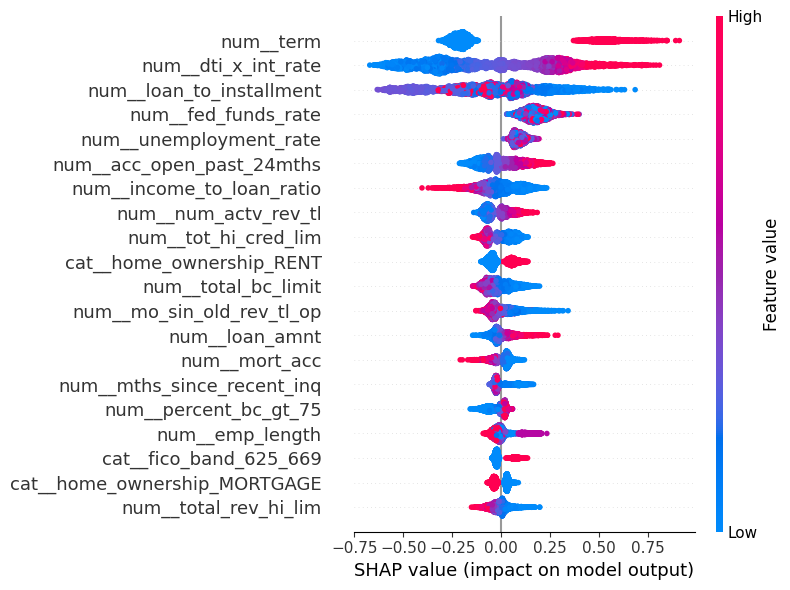

In [41]:
shap.summary_plot(shap_values, 
                  X_shap, 
                  feature_names=feature_names, 
                  max_display=20,
                  plot_size=(8, 6))

The beeswarm plot adds direction to the importance ranking. Key patterns:

- **`term`**: high values (long-term loans, red) push strongly toward default; short-term
  loans cluster near zero — the most asymmetric effect in the model
- **`dti_x_int_rate`**: high values increase default risk substantially; the effect is
  right-skewed with extreme positive SHAP values for the most stressed borrowers
- **`loan_to_installment`**: high values shift predictions away from default (negative
  SHAP), consistent with larger loans relative to installment implying shorter effective
  duration
- **`fed_funds_rate`**: high rate environments (red) shift predictions toward default,
  capturing the credit cycle effects
- **`unemployment_rate`**: high unemployment (red) is mildly associated with lower default
  risk — likely a composition effect where early high-unemployment vintages had tighter
  underwriting
- **`income_to_loan_ratio`**: high values reduce default risk, consistent with stronger
  repayment capacity
- **Credit capacity variables** (`tot_hi_cred_lim`, `total_bc_limit`): high values shift
  predictions away from default (blue shifts left), confirming that approved limits proxy
  for borrower quality

Most remaining features show symmetric, narrow distributions centered near zero,
indicating modest and well-behaved marginal effects across the population.

### 🔷 5.4: Dependence plots for top features

Dependence plots show how SHAP values change as a function of a single feature. The color encodes a second feature automatically chosen by SHAP to reveal interactions.

Note that SHAP automatically selects the interaction feature (color) by finding the variable that has the strongest interaction effect with the focal feature. Specifically, the feature whose values explain the most residual variance in the SHAP values after the main effect is removed.

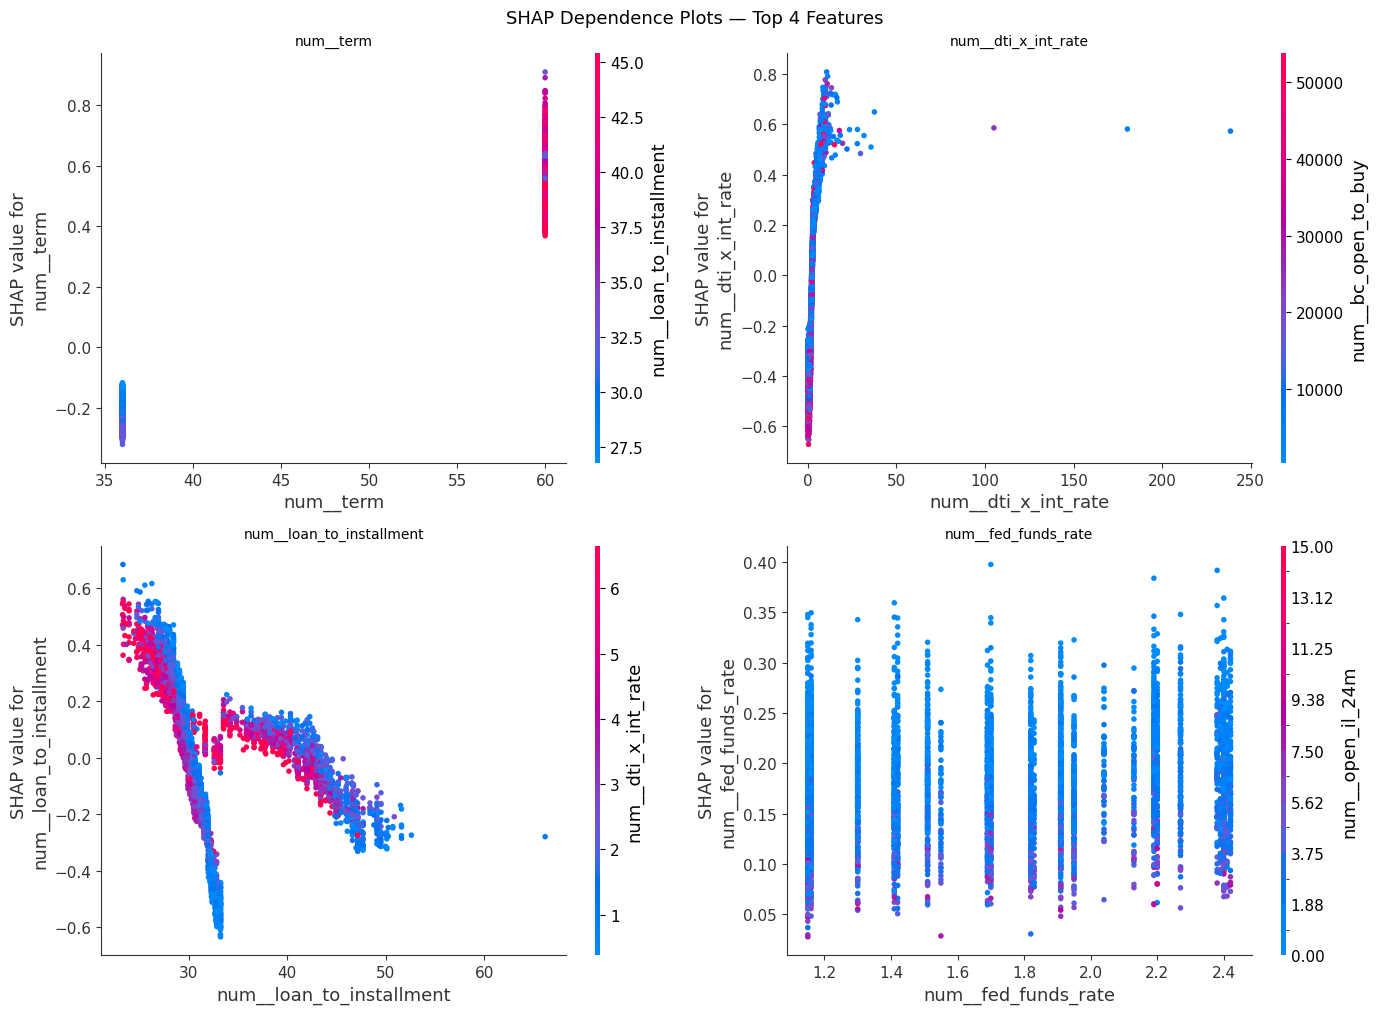

In [43]:
# Identify top features by mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argsort(mean_abs_shap)[::-1][:4]
top_feature_names = [feature_names[i] for i in top_feature_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat_name in zip(axes.flatten(), top_feature_names):
    feat_idx = list(feature_names).index(feat_name)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_shap,
        feature_names=feature_names,
        ax=ax,
        show=False
    )
    ax.set_title(feat_name, fontsize=10)

plt.tight_layout()
plt.suptitle("SHAP Dependence Plots — Top 4 Features", fontsize=13, y=1.01)
plt.show()

Dependence plots show how each feature's SHAP value varies across its range, with color
indicating the feature SHAP identified as having the strongest interaction effect.

- **`term`**: A discrete two-value feature (36 vs. 60 months). Short-term loans (36)
  consistently reduce default risk, while 60-month loans sharply increase it — the most
  step-like effect in the model. Color (`loan_to_installment`) shows no meaningful
  gradient, suggesting the term effect is largely independent of loan size.

- **`dti_x_int_rate`**: SHAP values rise steeply at low values then flatten quickly,
  indicating a strong nonlinear threshold effect — moderate repayment stress already
  captures most of the default signal, with extreme values adding little incremental
  information. The interaction with `bc_open_to_buy` shows no clear pattern, suggesting
  the main effect dominates.

- **`loan_to_installment`**: A smooth, strongly negative relationship — higher values
  (larger loan relative to installment, i.e. shorter effective duration) reduce default
  risk monotonically. The interaction with `dti_x_int_rate` (color) shows no clear
  gradient, suggesting the main effect dominates and the duration effect operates
  largely independently of repayment stress.

- **`fed_funds_rate`**: SHAP values are strictly positive across all observed values,
  meaning higher rates consistently increase predicted default risk. The discrete vertical
  bands reflect the discrete nature of Fed rate changes over time. No strong interaction
  with `open_il_24m` is visible, suggesting the rate effect operates independently as a
  vintage-level risk factor.

Overall, the dependence plots reveal that the top features operate primarily through strong
main effects rather than interactions. The most notable nonlinearity is in `dti_x_int_rate`,
where the model captures a threshold effect between debt burden and borrowing cost that a
linear model cannot replicate.